<a href="https://colab.research.google.com/github/khaliljtaylor/california-housing-data-exploration/blob/main/HousingPricesDataExploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Housing Prices Data Exploration

## Import Necessary Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Loading/Reading the Dataset

Here we will work on the Californnia Census dataset csv file.

* First by loading the csv file: pd.read_csv()

* Then by printing intial rows: df.head()



In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv')

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Data Cleaning

In [ ]:
print('--- Data Cleaning: Handling Missing Values ---')
# Identify missing values
print("Missing values before handling:")
print(df.isnull().sum())

# Impute missing values in 'total_bedrooms' with the median
# From df.info(), 'total_bedrooms' is the only column with missing values.
median_total_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_total_bedrooms)

print("\nMissing values after handling:")
print(df.isnull().sum())

print('\n--- Data Cleaning: Checking for Duplicate Entries ---')
# Check for duplicate entries
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate entries before removal: {num_duplicates}")

# Remove duplicate entries if any
if num_duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Number of duplicate entries after removal: {df.duplicated().sum()}")
else:
    print("No duplicate entries found.")

print('\n--- Data Cleaning: Detecting and Correcting Outliers (Capping with IQR) ---')
# Function to detect and cap outliers using IQR
def cap_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers_count = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)].shape[0]
    if outliers_count > 0:
        print(f"Column '{column}': {outliers_count} outliers detected and will be capped.")
    else:
        print(f"Column '{column}': No significant outliers detected outside 1.5 IQR range.")

    # Cap outliers
    dataframe[column] = np.where(dataframe[column] < lower_bound, lower_bound, dataframe[column])
    dataframe[column] = np.where(dataframe[column] > upper_bound, upper_bound, dataframe[column])
    return dataframe

# Apply outlier capping to all numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numerical_cols:
    df = cap_outliers_iqr(df, col)

print("\nData cleaning steps completed: Missing values handled, duplicates removed, and outliers capped.")


--- Data Cleaning: Handling Missing Values ---
Missing values before handling:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Missing values after handling:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

--- Data Cleaning: Checking for Duplicate Entries ---
Number of duplicate entries before removal: 0
No duplicate entries found.

--- Data Cleaning: Detecting and Correcting Outliers (Capping with IQR) ---
Column 'longitude': No significant outliers detected outside 1.5 IQR range.
Column 'latitude': No significant outliers detected outside 1.5 IQR range.
Column 'housing_median_age

/tmp/ipykernel_509/124737018.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(median_total_bedrooms, inplace=True)


## Data Exploration/Visualization

### Summary of Statistics

In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2441.692472,501.182086,1336.959012,469.020107,3.801010,205981.224976
std,2.003532,2.135952,12.585558,1397.790038,284.133641,765.550830,265.507540,1.657658,113217.350152
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,5698.375000,1162.625000,3132.000000,1092.500000,8.013025,482412.500000


### Histograms for Numerial Features

Histograms are used to examine the distribution of numerical variables. They help identify patterns such as skewness, spread, and potential outliers.

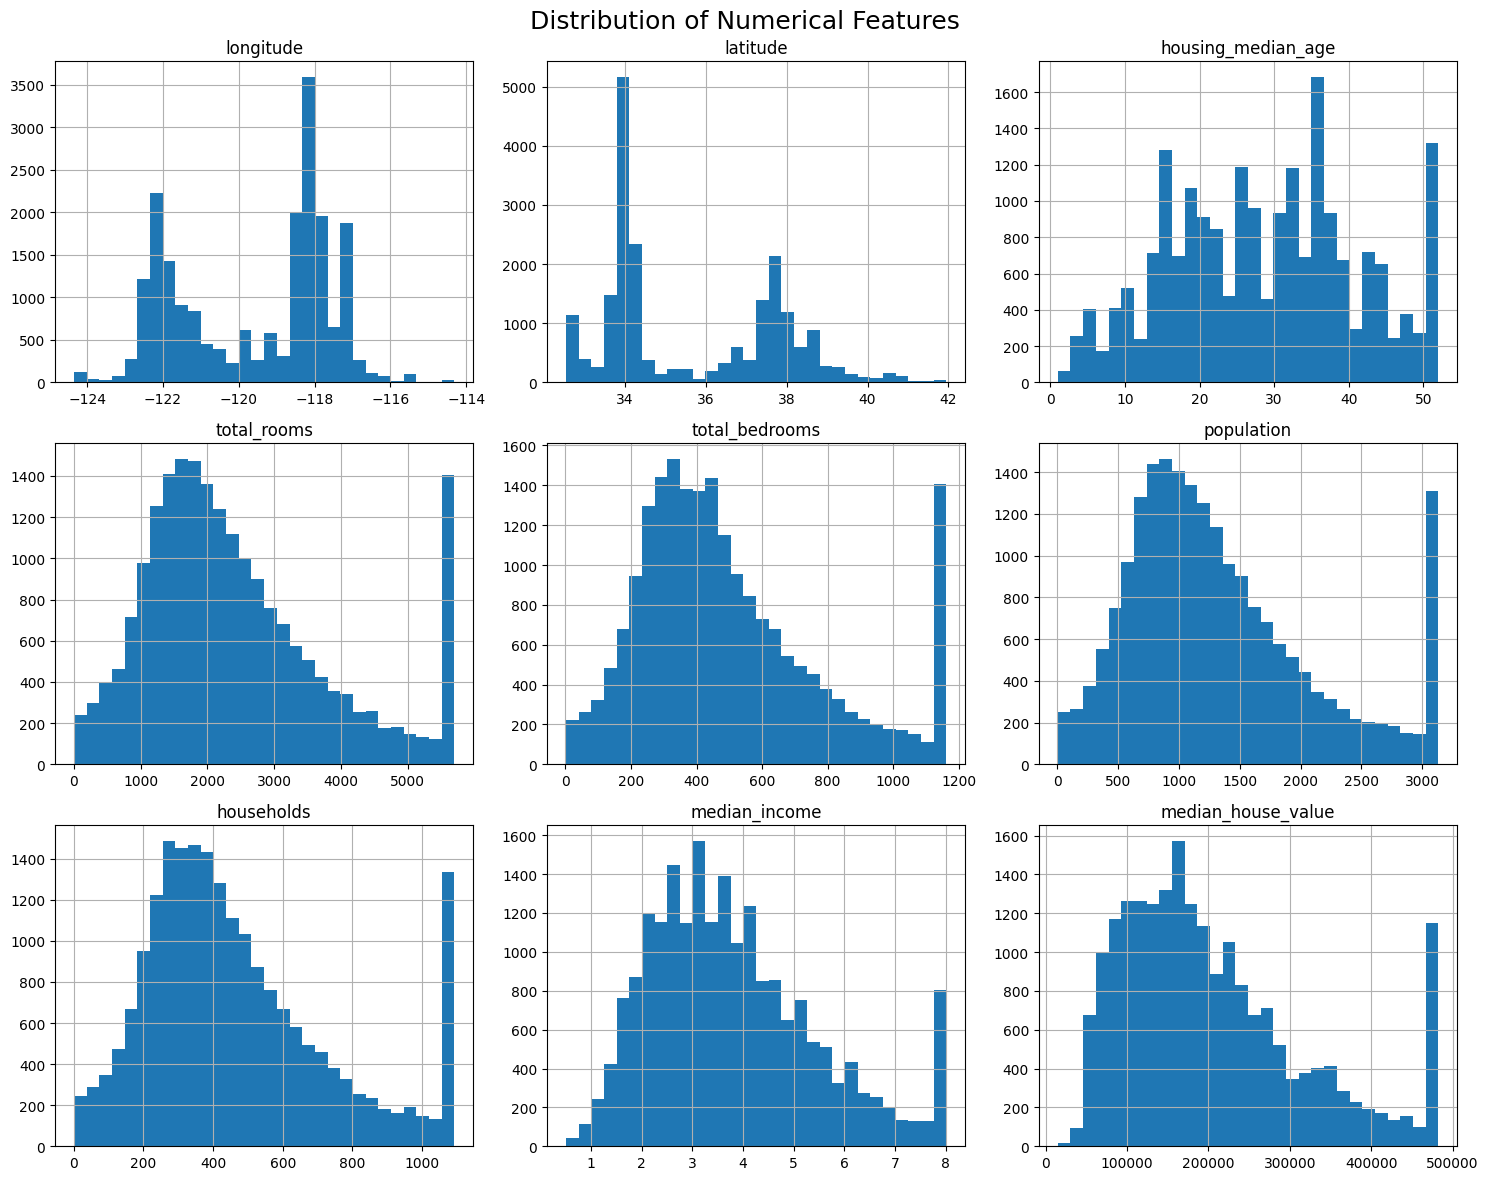

In [ ]:
# Select only numerical columns
df_num = df.select_dtypes(include=['float64', 'int64'])

# Create histograms
df_num.hist(figsize=(15, 12), bins=30)

plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.tight_layout()
plt.show()

### Box Plots

Box plots summarize the distribution of numerical features and highlight potential outliers. They also show the median and variability of the data.

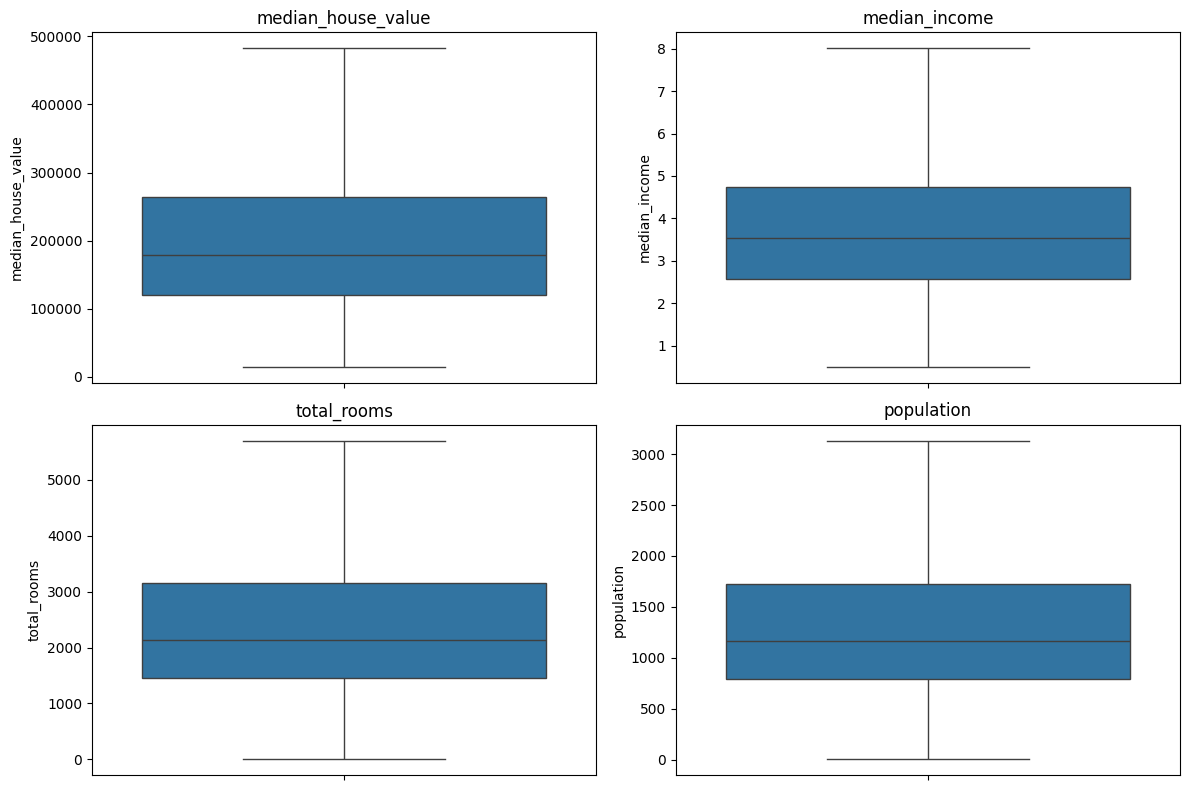

In [ ]:
numerical_columns = [
    'median_house_value',
    'median_income',
    'total_rooms',
    'population'
]

plt.figure(figsize=(12, 8))

for i, column in enumerate(numerical_columns):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

### Bar Chart for the Categorical Feature

A bar chart displays the frequency of each category in the `ocean_proximity` feature. This helps identify the most and least common categories in the dataset.

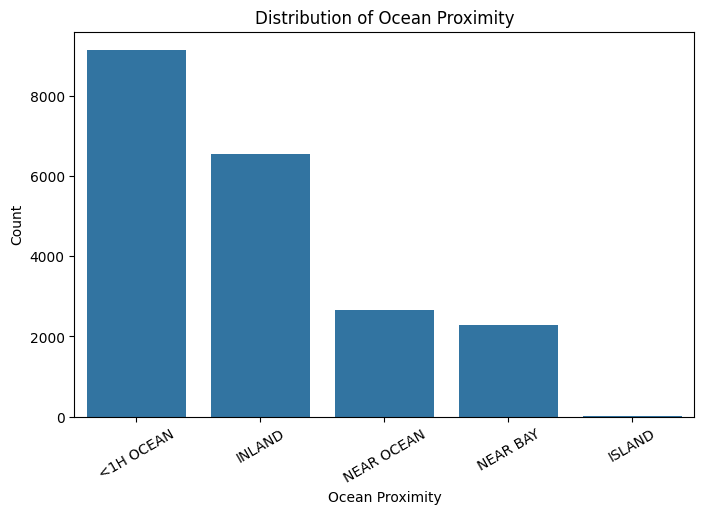

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='ocean_proximity',
    order=df['ocean_proximity'].value_counts().index
)

plt.title("Distribution of Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.show()

### Scatter Plot: Median Income vs Median House Value

This scatter plot explores the relationship between median income and median house value. It helps determine whether higher income levels are associated with higher housing prices.

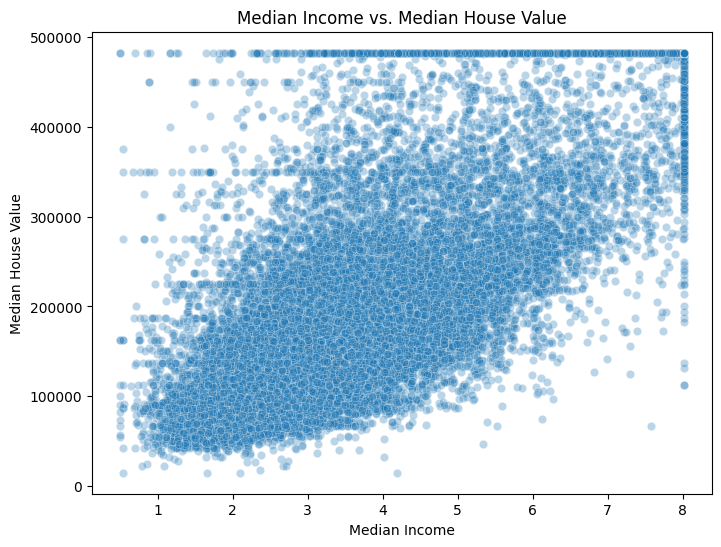

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='median_income',
    y='median_house_value',
    alpha=0.3
)

plt.title("Median Income vs. Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")

plt.show()

### Scatter Plot: Total Rooms vs. Median House Value

This visualization examines the relationship between the total number of rooms and median house value. It helps identify whether larger housing areas tend to have higher prices.

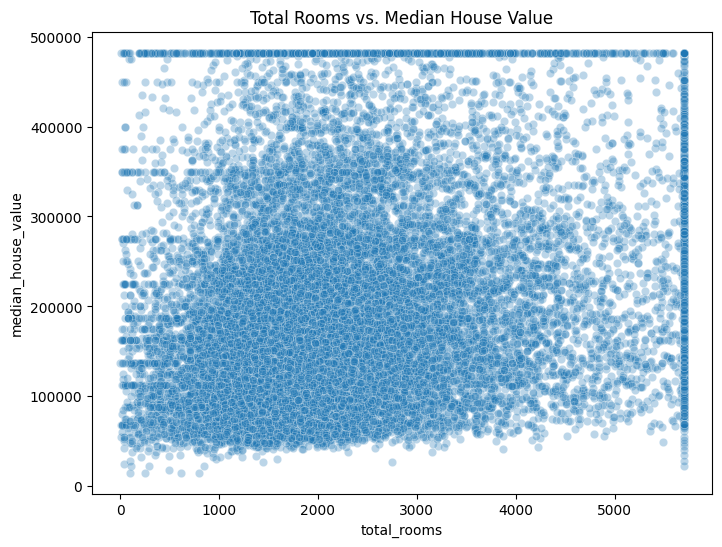

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='total_rooms',
    y='median_house_value',
    alpha=0.3
)

plt.title("Total Rooms vs. Median House Value")

plt.show()

### Scatter Plot: Population vs. Median House Value

This scatter plot shows the relationship between population and median house value. It can reveal whether population density is associated with housing prices.

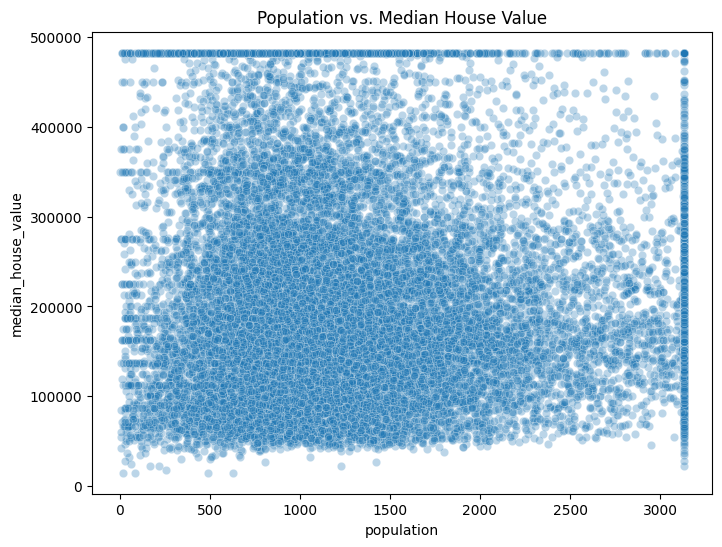

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='population',
    y='median_house_value',
    alpha=0.3
)

plt.title("Population vs. Median House Value")

plt.show()

### Correlation Matrix

The correlation matrix measures the strength and direction of relationships between numerical variables. Correlation values range from -1 to 1.

In [ ]:
correlation_matrix = df_num.corr()

correlation_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.029832,0.062197,0.116115,0.054723,-0.015461,-0.046311
latitude,-0.924664,1.000000,0.011173,-0.028146,-0.066318,-0.133225,-0.079117,-0.084654,-0.145494
housing_median_age,-0.108197,0.011173,1.000000,-0.381712,-0.327458,-0.307620,-0.307402,-0.142435,0.104423
total_rooms,0.029832,-0.028146,-0.381712,1.000000,0.912317,0.828494,0.909489,0.251895,0.173622
total_bedrooms,0.062197,-0.066318,-0.327458,0.912317,1.000000,0.867629,0.972184,-0.012738,0.062042
population,0.116115,-0.133225,-0.307620,0.828494,0.867629,1.000000,0.904272,0.000984,-0.030735
households,0.054723,-0.079117,-0.307402,0.909489,0.972184,0.904272,1.000000,0.017790,0.080980
median_income,-0.015461,-0.084654,-0.142435,0.251895,-0.012738,0.000984,0.017790,1.000000,0.689654
median_house_value,-0.046311,-0.145494,0.104423,0.173622,0.062042,-0.030735,0.080980,0.689654,1.000000


### Correlation Heatmap

The heatmap provides a visual representation of the correlation matrix. Strong positive and negative relationships are easier to identify using color intensity.

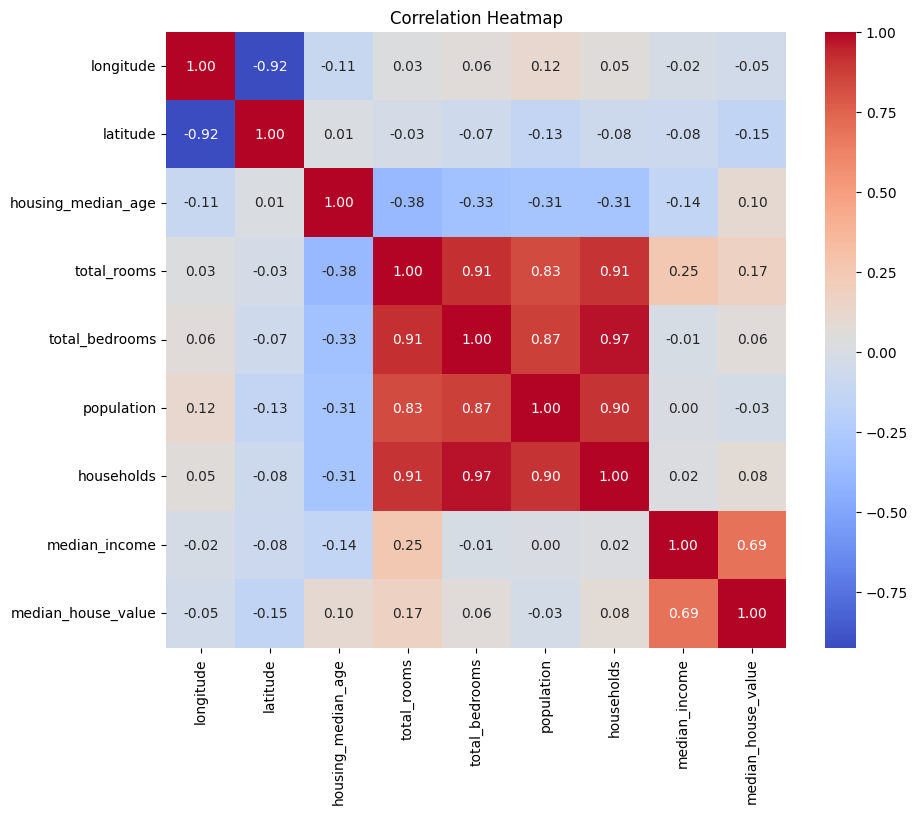

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Correlation with Median House Value

This heatmap highlights the correlation of each numerical feature with the target variable, `median_house_value`. It helps identify the features that are most strongly related to housing prices.

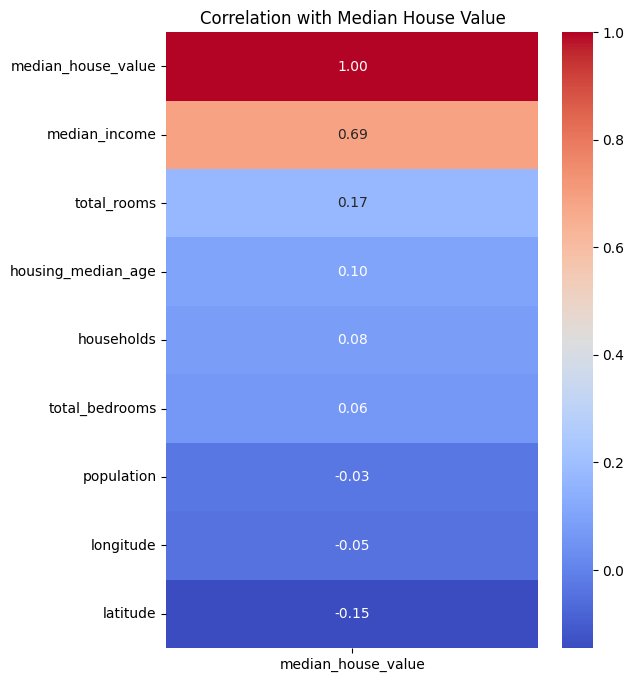

In [ ]:
plt.figure(figsize=(6,8))

housing_corr = (
    correlation_matrix[['median_house_value']]
    .sort_values(by='median_house_value', ascending=False)
)

sns.heatmap(
    housing_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation with Median House Value")

plt.show()